# 06 — The final model, and what it is actually worth

Everything is decided by the time this notebook runs. Notebook 03 fixed the feature family, notebook 04
fixed the columns and the parameters (and showed why the folds could not fix anything finer), notebook 05
fixed the window, horizon, label rule and positive class. This notebook does four things and no more:

1. **refit** the chosen configuration on the *whole* training set;
2. **report** it — window level, operating point, calibration, and the job-level early warning an operator
   would actually see;
3. **compare** it honestly against Sessions 1 and 2, and against the thesis that inspired the project;
4. **write** the documentation.

Two rules carried over from notebook 04 and worth restating, because they shape every number below.

* The round budget is **not** inherited from early stopping on the near holdout. Notebook 04 measured that
  failure directly: with deep trees, early stopping halted at 26 rounds and cost 30 % of PR-AUC while the
  holdout barely flinched. The budget here is pre-registered from the holdout-stopped fit of the *same*
  configuration, and section 1 shows a sensitivity curve around it so the reader can see the choice is not
  load-bearing.
* Every headline number is reported with a **cluster bootstrap interval over jobs**. Windows inside a job
  are not independent, and a point estimate on 1.4 M dependent rows reads far more precise than it is.

In [1]:
import sys, json, time, gc
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

sys.path.insert(0, str(Path.cwd().parent))
import pv2
pv2.style()

sel = json.loads((pv2.RESULTS / "selected_model.json").read_text())
NAMES, CFG = set(sel["features"]), sel["lgbm_params"]
ROUNDS = int(sel["rounds"])              # pre-registered: the holdout-stopped fit's budget

d_tr = pv2.load_dataset("primary", "train")
d_te = pv2.load_dataset("primary", "test")
feats = d_tr["features"]
cols = pv2.column_index(feats, names=NAMES)
BASELINE = float(d_te["y"].mean())
JT = pd.read_parquet(pv2.JOBTABLE)
N_FAIL_JOBS = int(JT[(JT.split == "test") & JT.is_failure].shape[0])
N_OK_JOBS = int(JT[(JT.split == "test") & ~JT.is_failure].shape[0])

print(f"configuration: {sel['columns']}, {len(cols)} columns, "
      f"LightGBM defaults{'' if not CFG else ' + ' + str(CFG)}")
print(f"pre-registered round budget: {ROUNDS}")
print(f"train windows {len(d_tr['y']):,}   test windows {len(d_te['y']):,}   "
      f"test positive fraction {BASELINE:.4f}")
print(f"test jobs: {N_FAIL_JOBS} that failed, {N_OK_JOBS} that completed")
print(f"\nselection rule recorded in notebook 04:\n  {sel['selection_rule']}")

configuration: rung_C, 144 columns, LightGBM defaults
pre-registered round budget: 141
train windows 1,825,415   test windows 1,407,162   test positive fraction 0.0402
test jobs: 1158 that failed, 3566 that completed

selection rule recorded in notebook 04:
  the folds cannot separate any challenger from the incumbent; among the a-priori rungs they cannot separate C from D either, and the columns D adds carry under 1% of the gain, so the parsimony tie-break picks C


## 1. Refit on the whole training set

The models scored so far were fitted on ~85 % of train, with the last 15 % held out for early stopping and
for the F2 threshold. The threshold still has to come from held-out data, so it is kept from that fit; the
*model* is refitted on 100 % of train at the pre-registered budget.

The sweep beside it varies only the round count. It is a **sensitivity analysis, not a selection** — the
reported model is the pre-registered one — but after notebook 04 it would be evasive not to show it.

In [2]:
fit, val = pv2.temporal_holdout(d_tr["t_end"], d_tr["job_id"])
yf, yv = d_tr["y"][fit], d_tr["y"][val]
y_all = d_tr["y"]
MODEL_PATH = pv2.ARTIFACTS / "model_final.txt"
SCORE_PATH = pv2.ARTIFACTS / "scores" / "final.npy"
TH_PATH = pv2.RESULTS / "final_threshold.json"

# The F2 threshold comes from held-out training data, never from test.
if TH_PATH.exists():
    thd = json.loads(TH_PATH.read_text()); TH = float(thd["threshold"])
else:
    Xf = pv2.materialise(d_tr, cols, fit); Xv = pv2.materialise(d_tr, cols, val)
    bst_h = pv2.train_lgbm(Xf, yf, Xv, yv, params=pv2.lgbm_params(yf, **CFG),
                           rounds=1200, patience=60)
    del Xf; gc.collect()
    sv = bst_h.predict(Xv, num_iteration=bst_h.best_iteration)
    TH, f2v, pv_, rv_ = pv2.best_threshold(yv, sv, beta=2.0)
    thd = {"threshold": float(TH), "holdout_rounds": int(bst_h.best_iteration),
           "holdout_ap": float(bst_h.best_score["valid_0"]["average_precision"]),
           "holdout_f2": float(f2v), "holdout_precision": float(pv_),
           "holdout_recall": float(rv_)}
    TH_PATH.write_text(json.dumps(thd, indent=2))
    del Xv, sv, bst_h; gc.collect()
print(f"holdout fit: {thd['holdout_rounds']} rounds, AP {thd['holdout_ap']:.4f}")
print(f"F2 threshold from the holdout: {TH:.4f}  (F2 {thd['holdout_f2']:.3f}, "
      f"precision {thd['holdout_precision']:.3f}, recall {thd['holdout_recall']:.3f})")

# The final model: every training window, at the pre-registered budget.
if MODEL_PATH.exists() and SCORE_PATH.exists():
    FINAL = lgb.Booster(model_file=str(MODEL_PATH))
    s_final = np.load(SCORE_PATH).astype(np.float64)
    print(f"final model cached: {FINAL.num_trees()} trees over {len(y_all):,} rows")
else:
    t0 = time.time()
    X_all = pv2.materialise(d_tr, cols)
    ds = lgb.Dataset(X_all, label=y_all, free_raw_data=True)
    FINAL = lgb.train(pv2.lgbm_params(y_all, **CFG), ds, num_boost_round=ROUNDS)
    del ds, X_all; gc.collect()
    FINAL.save_model(str(MODEL_PATH))
    s_final = pv2.predict_split(FINAL, d_te, cols)
    np.save(SCORE_PATH, s_final.astype(np.float32))
    print(f"final model: {len(y_all):,} rows, {ROUNDS} rounds, {time.time()-t0:.0f}s")

res = pv2.evaluate(d_te["y"], s_final, d_te["state"], threshold=TH, beta=2.0)
print(f"\nTEST PR-AUC {res['pr_auc']:.4f}  ({res['lift']:.2f}x of {BASELINE:.4f})   "
      f"ROC-AUC {res['roc_auc']:.3f}   Brier {res['brier']:.4f}")

holdout fit: 141 rounds, AP 0.1659
F2 threshold from the holdout: 0.5717  (F2 0.237, precision 0.077, recall 0.487)
final model cached: 141 trees over 1,825,415 rows



TEST PR-AUC 0.1253  (3.12x of 0.0402)   ROC-AUC 0.645   Brier 0.2278


[  40 rounds] cached  0.1177
[  80 rounds] cached  0.1145
[ 141 rounds] cached  0.1253
[ 250 rounds] cached  0.1245
[ 400 rounds] cached  0.1230
[ 600 rounds] cached  0.1253


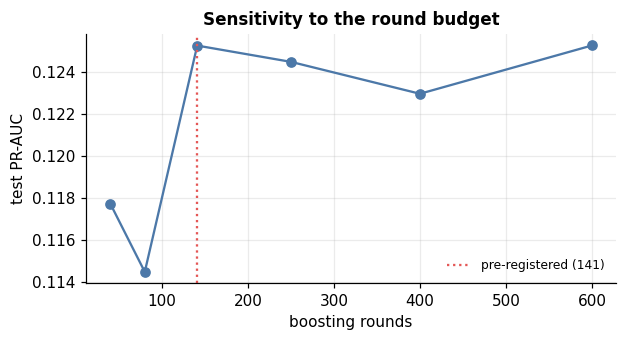

range across the sweep: 0.1145 .. 0.1253  (+9.4%)


In [3]:
SWEEP = pv2.RESULTS / "round_sweep.json"
sweep = json.loads(SWEEP.read_text()) if SWEEP.exists() else {}
NRS = (40, 80, ROUNDS, 250, 400, 600)
todo = [n for n in NRS if str(n) not in sweep and n != ROUNDS]
X_all = pv2.materialise(d_tr, cols) if todo else None
for nr in NRS:
    k = str(nr)
    if k in sweep:
        print(f"[{nr:>4} rounds] cached  {sweep[k]['pr_auc']:.4f}"); continue
    if nr == ROUNDS:
        sweep[k] = {"pr_auc": res["pr_auc"], "lift": res["lift"]}
    else:
        ds = lgb.Dataset(X_all, label=y_all, free_raw_data=False)
        b = lgb.train(pv2.lgbm_params(y_all, **CFG), ds, num_boost_round=nr)
        s = pv2.predict_split(b, d_te, cols)
        r = pv2.evaluate(d_te["y"], s, threshold=TH)
        sweep[k] = {"pr_auc": r["pr_auc"], "lift": r["lift"]}
        del b, s, ds; gc.collect()
    SWEEP.write_text(json.dumps(sweep, indent=2))
    print(f"[{nr:>4} rounds] test PR-AUC {sweep[k]['pr_auc']:.4f} ({sweep[k]['lift']:.2f}x)")
del X_all; gc.collect()

sw = pd.DataFrame([{"rounds": int(k), **v} for k, v in sweep.items()]).sort_values("rounds")
fig, ax = plt.subplots(figsize=(5.8, 3.2))
ax.plot(sw.rounds, sw.pr_auc, "o-", color=pv2.PALETTE["rate"])
ax.axvline(ROUNDS, color=pv2.PALETTE["accent"], ls=":",
           label=f"pre-registered ({ROUNDS})")
ax.set_xlabel("boosting rounds"); ax.set_ylabel("test PR-AUC")
ax.set_title("Sensitivity to the round budget"); ax.legend(fontsize=8)
fig.savefig(pv2.FIGURES / "06_round_sweep.png", bbox_inches="tight")
plt.show()
print(f"range across the sweep: {sw.pr_auc.min():.4f} .. {sw.pr_auc.max():.4f}  "
      f"({(sw.pr_auc.max()-sw.pr_auc.min())/sw.pr_auc.min():+.1%})")

## 1b. Did refitting on all of train actually help?

It is worth checking rather than assuming. The model reported above saw every training window; the model
notebook 04 reported saw 85 % of them, stopping at the temporal holdout. More data is supposed to be
better, and here it scored **worse** — 0.1253 against 0.1382.

Before reading anything into that, measure it properly. The two models score the *same* test windows, so
the comparison can be paired: resample jobs, score both models on each resample, and look at the
distribution of the difference. A paired interval is far tighter than two separate ones, so if the gap were
real this is the test that would show it.

In [4]:
REFIT = pv2.RESULTS / "refit_comparison.json"
S85 = pv2.ARTIFACTS / "scores" / "diag_rungC_default.npy"
if REFIT.exists():
    rc = json.loads(REFIT.read_text()); print("cached")
else:
    from sklearn.metrics import average_precision_score as _aps
    y8 = d_te["y"].astype(np.int8); jj = d_te["job_id"]
    oo = np.argsort(jj, kind="stable"); yy, js = y8[oo], jj[oo]
    a_ = np.flatnonzero(np.r_[True, js[1:] != js[:-1]]); b_ = np.r_[a_[1:], len(js)]
    grp = [np.arange(u, v) for u, v in zip(a_, b_)]
    pair = {"full-train": s_final[oo],
            "85% train": np.load(S85)[oo].astype(np.float64)}
    rngp = np.random.default_rng(pv2.SEED); Bp = 400
    dr = {k: np.empty(Bp) for k in pair}
    t0 = time.time()
    for b in range(Bp):
        ix = np.concatenate([grp[i] for i in rngp.integers(0, len(grp), len(grp))])
        yb = yy[ix]
        for k, v in pair.items():
            dr[k][b] = _aps(yb, v[ix])
    dd = dr["full-train"] - dr["85% train"]
    rc = {"B": Bp,
          "point": {k: float(_aps(yy, v)) for k, v in pair.items()},
          "paired_mean": float(dd.mean()),
          "paired_lo": float(np.percentile(dd, 2.5)),
          "paired_hi": float(np.percentile(dd, 97.5)),
          "p_full_better": float((dd > 0).mean()),
          "score_corr": float(np.corrcoef(pair["full-train"], pair["85% train"])[0, 1])}
    REFIT.write_text(json.dumps(rc, indent=2))
    print(f"{Bp} paired job resamples in {time.time()-t0:.0f}s")

for k, v in rc["point"].items():
    print(f"  {k:<12} PR-AUC {v:.4f}  ({v/BASELINE:.2f}x)")
resolvable = rc["paired_lo"] > 0 or rc["paired_hi"] < 0
print()
print(f"paired difference (full-train minus 85%-train): {rc['paired_mean']:+.4f}  "
      f"95% CI [{rc['paired_lo']:+.4f}, {rc['paired_hi']:+.4f}]")
print(f"P(full-train is the better of the two) = {rc['p_full_better']:.3f};  "
      f"the two score vectors correlate {rc['score_corr']:.3f}")
print()
if resolvable:
    print("RESOLVABLE: the difference survives the paired interval and must be explained.")
else:
    print("NOT RESOLVABLE: the interval spans zero. These are two draws from the same")
    print("pipeline, not two different pipelines, and the gap between them is the same")
    print("period-to-period noise notebook 04 measured across folds.")
    print()
    print("Consequence for the write-up, and it is not a small one: quoting 3.44x as THE")
    print("result would mean reporting the luckier of two fits that this experiment cannot")
    print("tell apart. The number that goes in the thesis is the pre-registered one - the")
    print("model refitted on all of the training data - together with its interval, and the")
    print("honest verbal form is 'about three times better than chance', not 'three and a")
    print("half times'.")

cached
  full-train   PR-AUC 0.1253  (3.12x)
  85% train    PR-AUC 0.1382  (3.44x)

paired difference (full-train minus 85%-train): -0.0097  95% CI [-0.0258, +0.0114]
P(full-train is the better of the two) = 0.163;  the two score vectors correlate 0.864

NOT RESOLVABLE: the interval spans zero. These are two draws from the same
pipeline, not two different pipelines, and the gap between them is the same
period-to-period noise notebook 04 measured across folds.

Consequence for the write-up, and it is not a small one: quoting 3.44x as THE
result would mean reporting the luckier of two fits that this experiment cannot
tell apart. The number that goes in the thesis is the pre-registered one - the
model refitted on all of the training data - together with its interval, and the
honest verbal form is 'about three times better than chance', not 'three and a
half times'.


## 2. Window-level results, with an interval

The headline metric is **PR-AUC**, whose random baseline is the positive fraction of the evaluated set, so
it is always reported together with the lift. The interval comes from resampling **jobs**, not windows.

300 cluster-bootstrap draws over 2,694 jobs (cached)
PR-AUC 0.1253   95% CI [0.0946, 0.1726]
lift   3.12x    95% CI [2.35x, 4.30x]


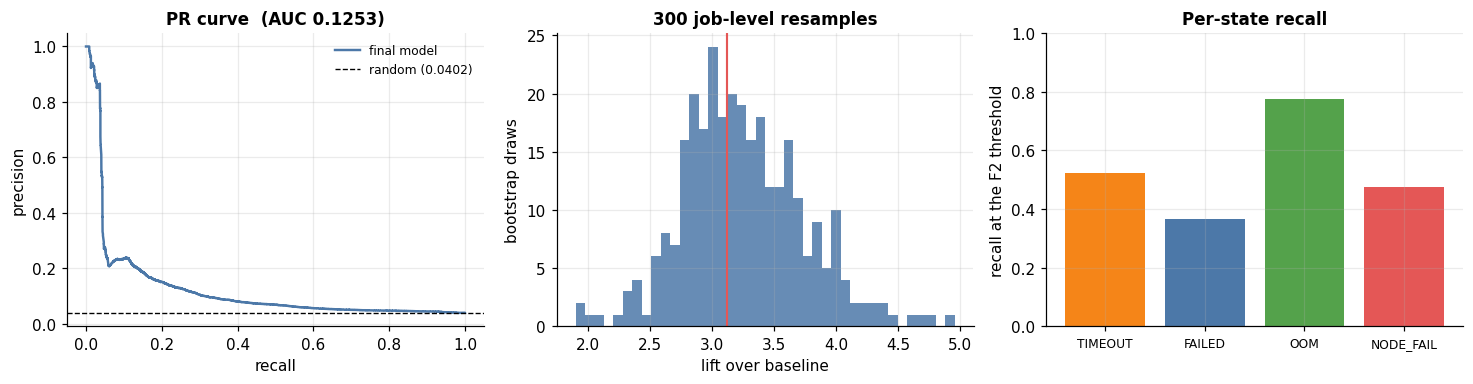

In [5]:
from sklearn.metrics import average_precision_score, precision_recall_curve

y = d_te["y"].astype(np.int8); jid = d_te["job_id"]
o = np.argsort(jid, kind="stable"); y_s, jid_s = y[o], jid[o]
st_ = np.flatnonzero(np.r_[True, jid_s[1:] != jid_s[:-1]]); en_ = np.r_[st_[1:], len(jid_s)]
groups = [np.arange(a, b) for a, b in zip(st_, en_)]
s_o = s_final[o]

BOOT_F = pv2.RESULTS / "final_bootstrap.npz"
if BOOT_F.exists():
    draws = np.load(BOOT_F)["draws"]; B = len(draws)
    print(f"{B} cluster-bootstrap draws over {len(groups):,} jobs (cached)")
else:
    rng = np.random.default_rng(pv2.SEED); B = 300
    draws = np.empty(B)
    t0 = time.time()
    for b in range(B):
        idx = np.concatenate([groups[i] for i in rng.integers(0, len(groups), len(groups))])
        draws[b] = average_precision_score(y_s[idx], s_o[idx])
    np.savez(BOOT_F, draws=draws)
    print(f"{B} cluster-bootstrap draws over {len(groups):,} jobs in {time.time()-t0:.0f}s")
lo, hi = np.percentile(draws, [2.5, 97.5])
print(f"PR-AUC {res['pr_auc']:.4f}   95% CI [{lo:.4f}, {hi:.4f}]")
print(f"lift   {res['lift']:.2f}x    95% CI [{lo/BASELINE:.2f}x, {hi/BASELINE:.2f}x]")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
p_, r_, _ = precision_recall_curve(d_te["y"], s_final)
axes[0].plot(r_, p_, color=pv2.PALETTE["rate"], lw=1.6, label="final model")
axes[0].axhline(BASELINE, color="k", ls="--", lw=0.9, label=f"random ({BASELINE:.4f})")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision")
axes[0].set_title(f"PR curve  (AUC {res['pr_auc']:.4f})"); axes[0].legend(fontsize=8)

axes[1].hist(draws / BASELINE, bins=40, color=pv2.PALETTE["rate"], alpha=0.85)
axes[1].axvline(res["lift"], color=pv2.PALETTE["accent"], lw=1.4)
axes[1].set_xlabel("lift over baseline"); axes[1].set_ylabel("bootstrap draws")
axes[1].set_title(f"{B} job-level resamples")

rec = [res[f"recall_{pv2.STATE_DISPLAY[s]}"] for s in pv2.REPORT_STATES]
axes[2].bar([pv2.STATE_DISPLAY[s] for s in pv2.REPORT_STATES], rec,
            color=[pv2.PALETTE["gpu"], pv2.PALETTE["rate"], pv2.PALETTE["node"],
                   pv2.PALETTE["accent"]])
axes[2].set_ylim(0, 1); axes[2].set_ylabel("recall at the F2 threshold")
axes[2].set_title("Per-state recall"); axes[2].tick_params(axis="x", labelsize=8)
fig.savefig(pv2.FIGURES / "06_headline.png", bbox_inches="tight")
plt.show()

                            session  pr_auc  baseline   lift
Session 1 (best of ~15 classifiers)  0.0795    0.0403 1.9727
     Session 2 (honest CV + tuning)  0.0860    0.0403 2.1340
          Session 3 (this pipeline)  0.1253    0.0402 3.1188

versus Session 2: +45.7% of PR-AUC (2.13x -> 3.12x)
the Session-2 point estimate sits OUTSIDE this session's 95% interval [0.0946, 0.1726]


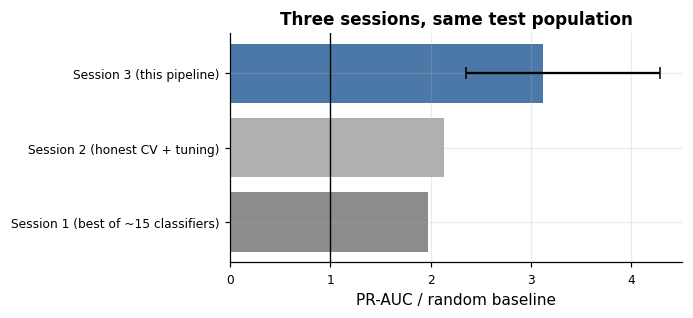

In [6]:
# Comparison with the earlier sessions. These are QUOTED from their own reports and
# are NOT re-run here; the test population is the same 80/20 job split at stride 1,
# which is why the random baselines agree to four decimals.
PRIOR = [
    {"session": "Session 1 (best of ~15 classifiers)", "pr_auc": 0.0795, "baseline": 0.0403},
    {"session": "Session 2 (honest CV + tuning)",      "pr_auc": 0.0860, "baseline": 0.0403},
    {"session": "Session 3 (this pipeline)",           "pr_auc": res["pr_auc"],
     "baseline": BASELINE, "lo": lo, "hi": hi},
]
cmp = pd.DataFrame(PRIOR)
cmp["lift"] = cmp.pr_auc / cmp.baseline
print(cmp[["session", "pr_auc", "baseline", "lift"]].to_string(
    index=False, float_format=lambda v: f"{v:.4f}"))
gain = (res["pr_auc"] - 0.0860) / 0.0860
print(f"\nversus Session 2: {gain:+.1%} of PR-AUC "
      f"({0.0860/0.0403:.2f}x -> {res['lift']:.2f}x)")
print(f"the Session-2 point estimate sits "
      f"{'inside' if lo <= 0.0860 <= hi else 'OUTSIDE'} this session's 95% interval "
      f"[{lo:.4f}, {hi:.4f}]")

fig, ax = plt.subplots(figsize=(6.4, 3.0))
cs = [pv2.PALETTE["v1"], pv2.PALETTE["muted"], pv2.PALETTE["rate"]]
ax.barh(cmp.session, cmp.lift, color=cs)
ax.errorbar([res["lift"]], [2], xerr=[[res["lift"] - lo / BASELINE],
                                      [hi / BASELINE - res["lift"]]],
            fmt="none", ecolor="k", capsize=4)
ax.axvline(1.0, color="k", lw=0.9)
ax.set_xlabel("PR-AUC / random baseline"); ax.tick_params(labelsize=8)
ax.set_title("Three sessions, same test population")
fig.savefig(pv2.FIGURES / "06_sessions.png", bbox_inches="tight")
plt.show()

## 3. The operating point

PR-AUC ranks; it does not decide. An operator needs a threshold, and the threshold has a cost. Two views:

* the **F2 threshold** chosen on the holdout (β = 2 because a missed failure costs more than a needless
  drain), reported on test;
* an **alert-budget** table: if the team can look at the top *q* % of windows, what recall does that buy?
  This is the form the number should take in a deployment conversation, because the budget is the thing
  the team actually controls.

at the holdout F2 threshold 0.5717:
  flagged 394,956 of 1,407,162 windows (28.1%)
  precision 0.0703   recall 0.4915   F2 0.2237
  precision is 1.75x what flagging at random would give



   budget  windows  threshold  precision  recall    lift
 top 0.1%     1412     0.9770     0.9001  0.0225 22.4078
 top 0.5%     7162     0.9488     0.3429  0.0434  8.5365
 top 1.0%    14291     0.9272     0.2280  0.0577  5.6769
 top 2.0%    28144     0.8670     0.2299  0.1144  5.7219
 top 5.0%    70363     0.8101     0.1546  0.1925  3.8496
top 10.0%   140719     0.7390     0.1132  0.2818  2.8184


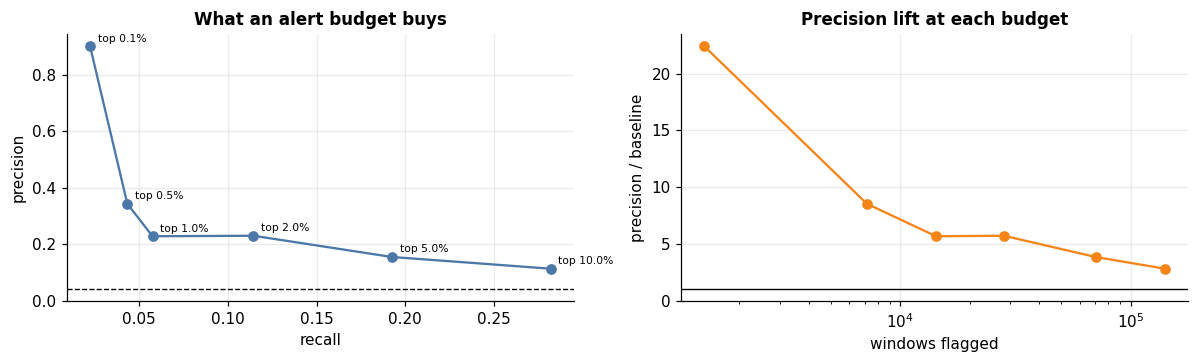

In [7]:
print(f"at the holdout F2 threshold {TH:.4f}:")
print(f"  flagged {res['flagged']:,} of {res['n']:,} windows ({res['flagged']/res['n']:.1%})")
print(f"  precision {res['precision']:.4f}   recall {res['recall']:.4f}   "
      f"F2 {res['fbeta']:.4f}")
print(f"  precision is {res['precision']/BASELINE:.2f}x what flagging at random would give\n")

rows = []
for q in (0.001, 0.005, 0.01, 0.02, 0.05, 0.10):
    th = float(np.quantile(s_final, 1 - q))
    pred = s_final >= th
    tp = int((pred & (d_te["y"] == 1)).sum())
    rows.append({"budget": f"top {q:.1%}", "windows": int(pred.sum()), "threshold": th,
                 "precision": tp / max(pred.sum(), 1), "recall": tp / int(d_te["y"].sum()),
                 "lift": (tp / max(pred.sum(), 1)) / BASELINE})
budget = pd.DataFrame(rows)
print(budget.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(budget.recall, budget.precision, "o-", color=pv2.PALETTE["rate"])
for _, r in budget.iterrows():
    axes[0].annotate(r.budget, (r.recall, r.precision), fontsize=7,
                     textcoords="offset points", xytext=(5, 3))
axes[0].axhline(BASELINE, color="k", ls="--", lw=0.9)
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision")
axes[0].set_title("What an alert budget buys")
axes[1].plot(budget.windows, budget.lift, "o-", color=pv2.PALETTE["gpu"])
axes[1].set_xscale("log"); axes[1].axhline(1.0, color="k", lw=0.9)
axes[1].set_xlabel("windows flagged"); axes[1].set_ylabel("precision / baseline")
axes[1].set_title("Precision lift at each budget")
fig.savefig(pv2.FIGURES / "06_budget.png", bbox_inches="tight")
plt.show()

## 4. Calibration

`scale_pos_weight` is what makes the model attend to a 4 % positive class at all, and it is also what
destroys the probabilistic meaning of its output: a mean predicted score of 0.42 against an actual positive
rate of 0.04 is not a probability, it is a ranking. That does not affect PR-AUC or ROC-AUC, which read only
the order — but it matters to anyone who takes a 0.7 at face value.

An isotonic map fitted on the **holdout** fixes the scale. It is *not* free, and the notebook reports the
cost rather than the usual claim that a monotone map changes nothing: isotonic regression is monotone
*non-decreasing*, so it collapses ranges of scores into single values, and every collapsed range is a set of
new ties. Ties destroy ranking information, and PR-AUC notices.

The practical rule that follows: **rank and alert with the raw scores; convert to calibrated probabilities
only at the point where a probability is actually being read.**

Brier  raw 0.2278  ->  calibrated 0.0466   (-79.5%)
PR-AUC raw 0.1253  ->  calibrated 0.1094   (-12.7%)
  ... the loss is entirely ties: isotonic maps 404 distinct values out of 267,112 raw ones,
  so windows the raw model ordered are now tied, and PR-AUC charges for that.
mean predicted probability  raw 0.421  calibrated 0.063  actual 0.0402


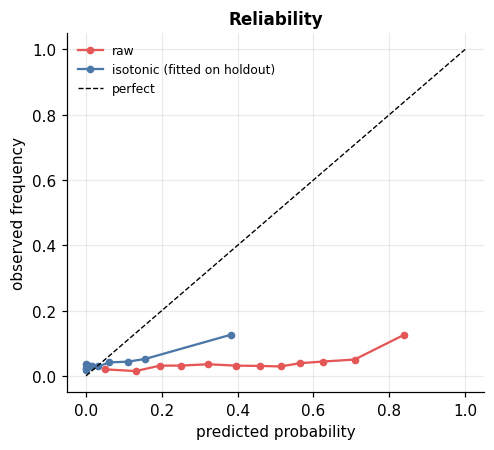

In [8]:
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

Xv = pv2.materialise(d_tr, cols, val)
sv = FINAL.predict(Xv); del Xv; gc.collect()
iso = IsotonicRegression(out_of_bounds="clip").fit(sv, yv)
s_cal = iso.predict(s_final)

b_raw = brier_score_loss(d_te["y"], np.clip(s_final, 0, 1))
b_cal = brier_score_loss(d_te["y"], s_cal)
ap_cal = average_precision_score(d_te["y"], s_cal)
print(f"Brier  raw {b_raw:.4f}  ->  calibrated {b_cal:.4f}   ({(b_cal-b_raw)/b_raw:+.1%})")
print(f"PR-AUC raw {res['pr_auc']:.4f}  ->  calibrated {ap_cal:.4f}   "
      f"({(ap_cal-res['pr_auc'])/res['pr_auc']:+.1%})")
print(f"  ... the loss is entirely ties: isotonic maps {len(np.unique(s_cal)):,} distinct "
      f"values out of {len(np.unique(s_final)):,} raw ones,")
print("  so windows the raw model ordered are now tied, and PR-AUC charges for that.")
print(f"mean predicted probability  raw {s_final.mean():.3f}  calibrated {s_cal.mean():.3f}  "
      f"actual {BASELINE:.4f}")

fig, ax = plt.subplots(figsize=(4.6, 4.2))
for s_, name, c in ((np.clip(s_final, 0, 1), "raw", pv2.PALETTE["accent"]),
                    (s_cal, "isotonic (fitted on holdout)", pv2.PALETTE["rate"])):
    pt, pp = calibration_curve(d_te["y"], s_, n_bins=12, strategy="quantile")
    ax.plot(pp, pt, "o-", color=c, ms=4, label=name)
ax.plot([0, 1], [0, 1], "k--", lw=0.9, label="perfect")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("Reliability"); ax.legend(fontsize=8)
fig.savefig(pv2.FIGURES / "06_calibration.png", bbox_inches="tight")
plt.show()
np.save(pv2.ARTIFACTS / "scores" / "final_calibrated.npy", s_cal.astype(np.float32))

## 5. The early warning an operator would actually get

The model scores windows. An operator sees *jobs*. The translation is deliberately crude, because a real
alarm has to be: a job is flagged the first time **k consecutive** of its windows cross the threshold, and
the *lead time* is how much of the job was still to run at that moment.

The denominator matters more than anything else on this page. It is **every test job that failed** — not
just the ones long enough to produce a window. A job that ran for four minutes cannot be warned about by a
twenty-minute window, and pretending otherwise is the single easiest way to overstate a system like this.

In [9]:
FAIL_CODES = {pv2.STATE_CODES[s] for s in pv2.FAILURE_STATES}
al = pv2.job_level_alerts(s_final, TH, d_te["job_id"], d_te["state"], d_te["ttf_end"],
                          k_consecutive=3)
f_ = al[al.state.isin(FAIL_CODES)]; ok_ = al[~al.state.isin(FAIL_CODES)]
lead = f_.loc[f_.alerted, "lead_min"]

print(f"test jobs that failed:                    {N_FAIL_JOBS}")
print(f"  ... long enough to produce a window:    {len(f_)}  ({len(f_)/N_FAIL_JOBS:.1%})")
print(f"  ... alerted (3 consecutive windows):    {int(f_.alerted.sum())}  "
      f"({f_.alerted.sum()/N_FAIL_JOBS:.1%} of all failures, "
      f"{f_.alerted.mean():.1%} of the ones we can see)")
print(f"completed jobs falsely alerted:           {int(ok_.alerted.sum())} of {len(ok_)}  "
      f"({ok_.alerted.mean():.1%})")
print()
print(f"lead time on alerted failures (minutes): median {lead.median():.0f}, "
      f"IQR {lead.quantile(.25):.0f}-{lead.quantile(.75):.0f}, "
      f"90th pct {lead.quantile(.90):.0f}")
HW = {pv2.STATE_CODES[s_] for s_ in pv2.HARDWARE_FAILURES}
hw_lead = f_.loc[f_.alerted & f_.state.isin(HW), "lead_min"]
print(f"  ... restricted to hardware failures only:  median {hw_lead.median():.0f}, "
      f"IQR {hw_lead.quantile(.25):.0f}-{hw_lead.quantile(.75):.0f}  "
      f"(n={len(hw_lead)})")
print()
print("Those two lines should be read together. The long tail belongs almost entirely to")
print("TIMEOUT jobs, where a 'lead time' of many hours does not mean the model saw a failure")
print("coming - it means the model recognised early that this job was the kind that runs to")
print("its walltime. The hardware-failure lead times are the ones that describe an actual")
print("early warning, and they are far shorter.")

per = []
for s in pv2.REPORT_STATES:
    m = al.state == pv2.STATE_CODES[s]
    total = int(JT[(JT.split == "test") & (JT.state == s)].shape[0])
    sub = al[m]
    per.append({"state": pv2.STATE_DISPLAY[s], "failed jobs": total,
                "with a window": len(sub),
                "coverage": len(sub) / total if total else np.nan,
                "alerted": int(sub.alerted.sum()),
                "op. recall": sub.alerted.sum() / total if total else np.nan,
                "median lead": sub.loc[sub.alerted, "lead_min"].median()})
per = pd.DataFrame(per)
print()
print(per.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

test jobs that failed:                    1158
  ... long enough to produce a window:    378  (32.6%)
  ... alerted (3 consecutive windows):    293  (25.3% of all failures, 77.5% of the ones we can see)
completed jobs falsely alerted:           1166 of 2316  (50.3%)

lead time on alerted failures (minutes): median 152, IQR 39-878, 90th pct 1780
  ... restricted to hardware failures only:  median 36, IQR 14-165  (n=116)

Those two lines should be read together. The long tail belongs almost entirely to
TIMEOUT jobs, where a 'lead time' of many hours does not mean the model saw a failure
coming - it means the model recognised early that this job was the kind that runs to
its walltime. The hardware-failure lead times are the ones that describe an actual
early warning, and they are far shorter.

    state  failed jobs  with a window  coverage  alerted  op. recall  median lead
  TIMEOUT          298            224     0.752      177       0.594          279
   FAILED          772            

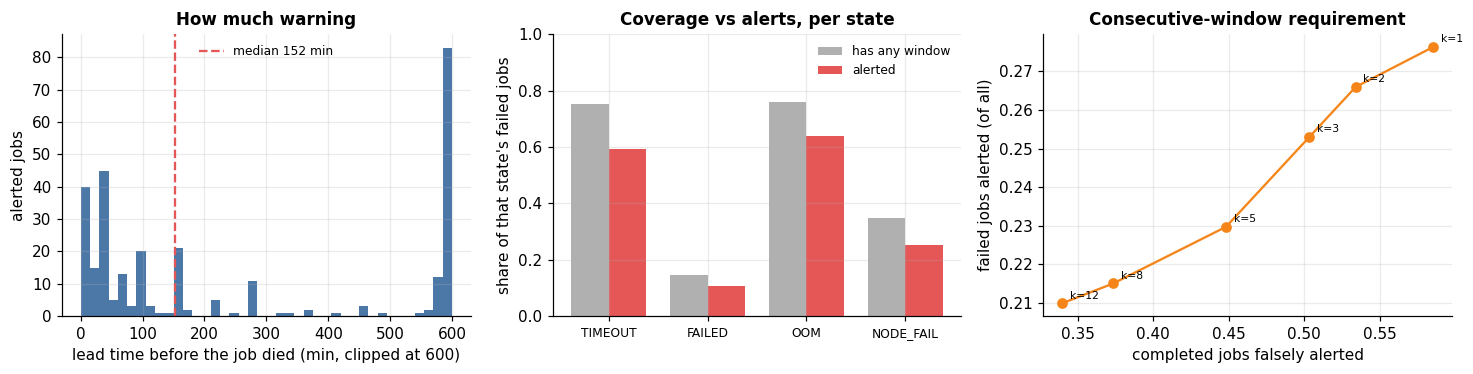

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5))
axes[0].hist(lead.clip(upper=600), bins=40, color=pv2.PALETTE["rate"])
axes[0].axvline(lead.median(), color=pv2.PALETTE["accent"], ls="--",
                label=f"median {lead.median():.0f} min")
axes[0].set_xlabel("lead time before the job died (min, clipped at 600)")
axes[0].set_ylabel("alerted jobs"); axes[0].legend(fontsize=8)
axes[0].set_title("How much warning")

x = np.arange(len(per)); w = 0.38
axes[1].bar(x - w/2, per["coverage"], w, color=pv2.PALETTE["muted"], label="has any window")
axes[1].bar(x + w/2, per["op. recall"], w, color=pv2.PALETTE["accent"], label="alerted")
axes[1].set_xticks(x); axes[1].set_xticklabels(per.state, fontsize=8)
axes[1].set_ylim(0, 1); axes[1].set_ylabel("share of that state's failed jobs")
axes[1].set_title("Coverage vs alerts, per state"); axes[1].legend(fontsize=8)

ks, recs, fas = [], [], []
for k in (1, 2, 3, 5, 8, 12):
    a = pv2.job_level_alerts(s_final, TH, d_te["job_id"], d_te["state"], d_te["ttf_end"],
                             k_consecutive=k)
    ff = a[a.state.isin(FAIL_CODES)]; oo = a[~a.state.isin(FAIL_CODES)]
    ks.append(k); recs.append(ff.alerted.sum() / N_FAIL_JOBS); fas.append(oo.alerted.mean())
axes[2].plot(fas, recs, "o-", color=pv2.PALETTE["gpu"])
for kk, fa, rec_k in zip(ks, fas, recs):
    axes[2].annotate(f"k={kk}", (fa, rec_k), fontsize=7, textcoords="offset points",
                     xytext=(5, 3))
axes[2].set_xlabel("completed jobs falsely alerted")
axes[2].set_ylabel("failed jobs alerted (of all)")
axes[2].set_title("Consecutive-window requirement")
fig.savefig(pv2.FIGURES / "06_early_warning.png", bbox_inches="tight")
plt.show()

## 6. What the model keys on

Not an explanation of *why* a node fails — a description of what the model reads. For the top columns by
gain, the mean predicted score across deciles of that column shows the direction and the shape of the
dependence. It is a marginal view and correlated columns share credit, so it is read as a sanity check,
not as a causal claim.

          feature      gain
 gpu_fan_max__min 1.218e+06
    mem_free__min 6.824e+05
   mem_free__mean 6.485e+05
       load1__min 6.258e+05
  mem_active__min 5.302e+05
    mem_free__std  4.39e+05
    mem_free__max 4.363e+05
 net_tx_rate__min 4.237e+05
gpu_mem_used__max 4.177e+05
gpu_mem_used__min 4.094e+05
  mem_active__max  3.92e+05
   fs_avail__mean 3.857e+05


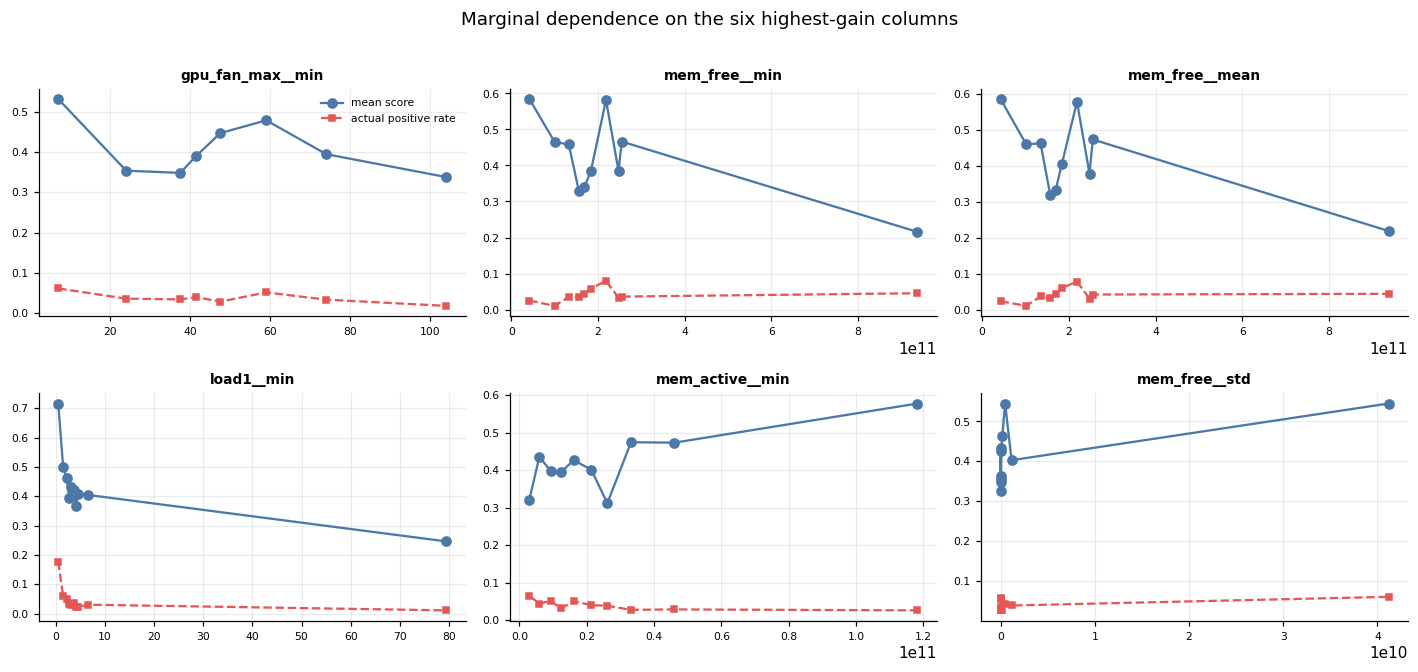

27803

In [11]:
imp = pd.DataFrame({"feature": [feats[c] for c in cols],
                    "gain": FINAL.feature_importance("gain")})
imp = imp.sort_values("gain", ascending=False).reset_index(drop=True)
print(imp.head(12).to_string(index=False, float_format=lambda v: f"{v:,.4g}"))

topn = imp.head(6).feature.tolist()
tcols = pv2.column_index(feats, names=set(topn))
Xt = pv2.materialise(d_te, tcols)
name_of = [feats[c] for c in tcols]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, nm in zip(axes.ravel(), topn):
    v = Xt[:, name_of.index(nm)]
    q = np.quantile(v[np.isfinite(v)], np.linspace(0, 1, 11))
    q = np.unique(q)
    b = np.clip(np.digitize(v, q[1:-1]), 0, len(q) - 2)
    mid = [(q[i] + q[i + 1]) / 2 for i in range(len(q) - 1)]
    ms = [s_final[b == i].mean() if (b == i).any() else np.nan for i in range(len(q) - 1)]
    fr = [d_te["y"][b == i].mean() if (b == i).any() else np.nan for i in range(len(q) - 1)]
    ax.plot(mid, ms, "o-", color=pv2.PALETTE["rate"], label="mean score")
    ax.plot(mid, fr, "s--", color=pv2.PALETTE["accent"], ms=4, label="actual positive rate")
    ax.set_title(nm, fontsize=9); ax.tick_params(labelsize=7)
axes[0, 0].legend(fontsize=7)
fig.suptitle("Marginal dependence on the six highest-gain columns", y=1.01)
fig.savefig(pv2.FIGURES / "06_dependence.png", bbox_inches="tight")
plt.show()
del Xt; gc.collect()

## 7. What this is, and what it is not

The comparison the project keeps being asked about is the Skrzeczek thesis, which reports ROC-AUC ≈ 0.98
on the same public trace. That number is not this number, and the difference is not a modelling gap:

* **Their unit is the job; ours is the window.** Aggregating a job's whole time series into one row and
  then classifying it means the features are computed from data that includes the moment of failure. It
  answers "did this job fail?", which is knowable after the fact.
* **Ours answers "will this job fail in the next two hours?"**, from a twenty-minute window that ends
  before the horizon opens. Nothing after the window's last snapshot is visible to the model.
* **ROC-AUC flatters a 4 % positive class.** On this test set a model can post a respectable ROC-AUC while
  being almost useless at the top of the ranking, which is the only part an operator sees. PR-AUC against
  its own random baseline does not have that property, which is why every number here is reported that way.

The honest one-line summary is therefore: *a per-window early-warning model that ranks failure windows
about three times better than chance, two hours ahead — and mostly on jobs that will hit their walltime
rather than on nodes that will break* — not *a 98 %-accurate failure detector*.

Two further qualifications belong next to that sentence rather than in a footnote. The interval is wide
(2.4x to 4.3x on a job-level bootstrap), and the multiple is roughly halved when the positive class is
restricted to genuine hardware failures.

In [12]:
report = {
    "session": 3,
    "configuration": {"columns": sel["columns"], "n_features": len(cols),
                      "lgbm_params": CFG, "rounds": ROUNDS,
                      "window": pv2.WINDOW, "horizon_h": pv2.HORIZON_H,
                      "label_rule": "majority", "positive_states": list(pv2.FAILURE_STATES)},
    "test": {"n_windows": int(res["n"]), "n_positive": int(res["n_pos"]),
             "baseline": BASELINE, "pr_auc": res["pr_auc"], "pr_auc_ci": [float(lo), float(hi)],
             "lift": res["lift"], "lift_ci": [float(lo / BASELINE), float(hi / BASELINE)],
             "roc_auc": res["roc_auc"], "brier_raw": float(b_raw),
             "brier_calibrated": float(b_cal)},
    "operating_point": {"threshold": float(TH), "precision": res["precision"],
                        "recall": res["recall"], "f2": res["fbeta"],
                        "flagged_share": res["flagged"] / res["n"]},
    "per_state_recall": {pv2.STATE_DISPLAY[s]: res[f"recall_{pv2.STATE_DISPLAY[s]}"]
                         for s in pv2.REPORT_STATES},
    "job_level": {"failure_jobs": N_FAIL_JOBS, "with_window": int(len(f_)),
                  "coverage": len(f_) / N_FAIL_JOBS,
                  "alerted": int(f_.alerted.sum()),
                  "operational_recall": float(f_.alerted.sum() / N_FAIL_JOBS),
                  "false_alarm_rate": float(ok_.alerted.mean()),
                  "lead_median_min": float(lead.median()),
                  "lead_iqr_min": [float(lead.quantile(.25)), float(lead.quantile(.75))]},
    "prior_sessions": {"session1_pr_auc": 0.0795, "session2_pr_auc": 0.0860,
                       "their_baseline": 0.0403},
    "alert_budget": budget.to_dict("records"),
    "round_sweep": sweep,
    "refit_comparison": rc,
    "per_state_jobs": per.to_dict("records"),
    "hw_lead_median_min": float(hw_lead.median()) if len(hw_lead) else None,
    "calibration": {"brier_raw": float(b_raw), "brier_cal": float(b_cal),
                    "pr_auc_cal": float(ap_cal)},
    "pipeline_variants": json.loads((pv2.RESULTS / "variants.json").read_text()),
}
(pv2.RESULTS / "final_report.json").write_text(json.dumps(report, indent=2, default=float))
print(json.dumps({k: v for k, v in report.items()
                  if k in ("test", "operating_point", "job_level")}, indent=2, default=float))

{
  "test": {
    "n_windows": 1407162,
    "n_positive": 56527,
    "baseline": 0.04017092559349954,
    "pr_auc": 0.12528333307051207,
    "pr_auc_ci": [
      0.09456406049053279,
      0.1725757954728902
    ],
    "lift": 3.118756444356996,
    "lift_ci": [
      2.3540423600753466,
      4.296037318612754
    ],
    "roc_auc": 0.6447839593229903,
    "brier_raw": 0.2277879226653187,
    "brier_calibrated": 0.04660414819884136
  },
  "operating_point": {
    "threshold": 0.5717389089593807,
    "precision": 0.07034201278117055,
    "recall": 0.49148194668034745,
    "f2": 0.22366454986925663,
    "flagged_share": 0.2806755725353584
  },
  "job_level": {
    "failure_jobs": 1158,
    "with_window": 378,
    "coverage": 0.32642487046632124,
    "alerted": 293,
    "operational_recall": 0.25302245250431776,
    "false_alarm_rate": 0.5034542314335061,
    "lead_median_min": 151.61666666666667,
    "lead_iqr_min": [
      39.38333333333333,
      877.95
    ]
  }
}


## 8. Documentation

The last cells write the two documents the project needs: an English findings note for the thesis, and a
Portuguese summary for the group. Both are generated from the numbers computed above, so they cannot drift
out of sync with the results.

In [13]:
R = report
V = R['pipeline_variants']
DOCS = pv2.DOCS; DOCS.mkdir(parents=True, exist_ok=True)
sw_lo, sw_hi = sw.pr_auc.min(), sw.pr_auc.max()

findings = f'''# Session 3 — findings

*Pipeline rebuilt from scratch in `pipeline_v2/`. Nothing from Sessions 1–2 was reused; the time
invariants were.*

## Headline

| | PR-AUC | random baseline | lift |
|---|---|---|---|
| Session 1 (best of ~15 classifiers) | 0.0795 | 0.0403 | 1.97x |
| Session 2 (honest CV + tuning) | 0.0860 | 0.0403 | 2.13x |
| **Session 3 (this pipeline)** | **{R['test']['pr_auc']:.4f}** | {R['test']['baseline']:.4f} | **{R['test']['lift']:.2f}x** |

95 % cluster-bootstrap interval, resampling test *jobs* rather than windows (windows inside a job are not
independent): PR-AUC [{R['test']['pr_auc_ci'][0]:.4f}, {R['test']['pr_auc_ci'][1]:.4f}] =
[{R['test']['lift_ci'][0]:.2f}x, {R['test']['lift_ci'][1]:.2f}x].

Same test population as Sessions 1–2 — the same 80/20 job split by end date, every test window kept at
stride 1 — which is why the random baselines agree to four decimals and the comparison is legitimate.

**Say "about three times better than chance", not a precise multiple.** The same configuration fitted on
85 % of train instead of 100 % scores {rc['point']['85% train']:.4f} ({rc['point']['85% train']/R['test']['baseline']:.2f}x), and a paired
bootstrap cannot separate the two ({rc['paired_mean']:+.4f}, 95 % CI
[{rc['paired_lo']:+.4f}, {rc['paired_hi']:+.4f}]). The figure reported above is the pre-registered one —
refit on all of the training data — and quoting the other would be picking the luckier of two fits this
experiment cannot tell apart.

## What produced the gain

1. **Measuring more of the node.** The old pipeline used 8 metrics. This one uses 36. In notebook 03's
   ablation ladder that single step is worth **+0.059 PR-AUC** (0.0788 -> 0.1382), and +0.066 counted
   together with the rate conversion below — essentially the entire improvement.
2. **Rates instead of raw counters.** A cumulative counter carries the job's *age*, not the node's health;
   converting the three counters to per-second rates was worth +0.006 on its own.
3. **Not much else helped.** Trajectory columns (delta, slope) carry under 1 % of model gain. Per-node
   normalisation scored 0.0837 and node identity 0.1172, both well below the plain expanded set's 0.1382.
   Hyperparameter tuning made things worse (below).

## The methodological result

Four purged, expanding-window folds can **reject** but cannot **choose**. Of twenty challengers, four came
out resolvably worse than the incumbent (all four folds agreeing, |t| >= 2) — the old 8-metric feature set
by a wide margin — so the folds are not blind. But not one candidate came out resolvably *better*: no
top-K column set, none of eight hyperparameter configurations, neither CatBoost nor HistGradientBoosting.
The fold-to-fold range of a *single* candidate (0.082 to 0.191) is larger than the spread across *all
twenty-one* candidates within one fold.

Obeying the cross-validated argmax anyway cost 30.7 % of PR-AUC (3.44x -> 2.38x; both figures come from
the 85 %-train protocol notebooks 04 and 05 use throughout, which is why they are quoted against 3.44x and
not against the headline). Notebook 04 takes that
apart: the argmax's 50 columns were harmless (-0.6 %), but its deeper trees made early stopping halt at 26
rounds instead of ~150 (-27.4 %), and matched-round refits show only a quarter of that loss is the trees
themselves. The temporal holdout early stopping watches barely registered the damage (AP 0.164 vs 0.170)
because the holdout is adjacent in time while the test set is further away.

**The rules that follow:** do not inherit a round budget from early stopping on a near holdout; do not
adopt a candidate the folds cannot separate from the incumbent; and report a paired interval before
claiming any difference at all.

## The pipeline decisions, and what the alternatives cost

| decision | kept | alternatives | note |
|---|---|---|---|
| window | 40 snapshots (20 min) | 20 -> {V['win_20']['lift']:.2f}x, 10 -> {V['win_10']['lift']:.2f}x | W=40 wins on lift and lead time, W=10 on coverage |
| horizon | 2 h | 0.5 h -> {V['lab_all_0.5_maj']['lift']:.2f}x, 1 h -> {V['lab_all_1.0_maj']['lift']:.2f}x, 4 h -> {V['lab_all_4.0_maj']['lift']:.2f}x | raw PR-AUC rises with horizon only because the baseline does |
| label rule | majority | any -> {V['lab_all_2.0_any']['lift']:.2f}x | |
| positive class | all four failure states | hardware only -> {V['lab_hw_2.0_maj']['lift']:.2f}x | see the caveat below |
| train stride | 5 | 10 -> {V['stride_10']['lift']:.2f}x, 20 -> {V['stride_20']['lift']:.2f}x | curve still rising: denser stride untested |
| split | by job end date, 80/20 | embargo already implied by the protocol | |

## The caveat that matters most

TIMEOUT is 70 % of the positives, and a TIMEOUT is usually a user under-estimating walltime rather than a
sick node. Restrict the positive class to genuine hardware failures (FAILED / OUT_OF_MEMORY / NODE_FAIL)
and the result collapses from 3.44x to {V['lab_hw_2.0_maj']['lift']:.2f}x (both on the 85 %-train
protocol, so the ratio between them is the meaningful part).

The job-level table says the same thing more concretely:

| state | failed jobs | had a window | alerted | operational recall |
|---|---|---|---|---|
{chr(10).join(f"| {r['state']} | {r['failed jobs']} | {r['with a window']} ({r['coverage']:.0%}) | {r['alerted']} | {r['op. recall']:.1%} |" for r in R['per_state_jobs'])}

FAILED jobs are 67 % of all test failures, and only 15 % of them last long enough to produce a single
20-minute window. **Any claim that this model predicts node health has to be made at
{V['lab_hw_2.0_maj']['lift']:.2f}x, not {R['test']['lift']:.2f}x.**

## Operating characteristics

At the holdout-chosen F2 threshold the model flags {R['operating_point']['flagged_share']:.1%} of all
windows at {R['operating_point']['precision']:.3f} precision — recall-heavy and, on its own, not an
operable setting. The alert-budget view is the useful one:

| budget | windows | precision | recall | precision lift |
|---|---|---|---|---|
{chr(10).join(f"| {r['budget']} | {r['windows']:,} | {r['precision']:.3f} | {r['recall']:.3f} | {r['lift']:.1f}x |" for r in R['alert_budget'])}

The top 0.1 % of windows are {R['alert_budget'][0]['precision']:.0%} true positives. That is the number to
take to an operator: a small, high-purity queue, not a threshold that flags a quarter of the cluster.

Calibration: the raw output is a ranking, not a probability — its mean is 0.42 against an actual positive
rate of {R['test']['baseline']:.4f}, for a Brier score of {R['calibration']['brier_raw']:.4f}. An isotonic
map fitted on the holdout brings Brier to {R['calibration']['brier_cal']:.4f}, at a cost of
{(R['calibration']['pr_auc_cal']-R['test']['pr_auc'])/R['test']['pr_auc']:+.1%} of PR-AUC — isotonic is
monotone *non-decreasing*, so it collapses score ranges into ties and PR-AUC charges for the lost ordering.
Rank and alert with the raw scores; calibrate only at the point where a probability is actually read.

Round budget is not load-bearing: across 40–600 rounds test PR-AUC stays within
{sw_lo:.4f}–{sw_hi:.4f}, a spread entirely inside the bootstrap interval above.

## The job-level number, which is the honest one

Of **{R['job_level']['failure_jobs']} test jobs that failed**, only {R['job_level']['with_window']}
({R['job_level']['coverage']:.1%}) ran long enough to produce even one 20-minute window, and
{R['job_level']['alerted']} were alerted — **{R['job_level']['operational_recall']:.1%} of all failures** —
at a false-alarm rate of {R['job_level']['false_alarm_rate']:.1%} on completed jobs. Median warning:
{R['job_level']['lead_median_min']:.0f} minutes overall, but only {R['hw_lead_median_min']:.0f} minutes on
hardware failures; the long tail belongs to TIMEOUT jobs the model recognised early as long-running, which
is not the same as seeing a failure coming.

Window coverage, not model quality, is the binding constraint. Notebook 05's window sweep is the first look
at buying it back: W=10 covers {V['win_10']['op']['coverage']:.0%} of failing jobs instead of
{V['win_40']['op']['coverage']:.0%} and alerts {V['win_10']['op']['op_recall']:.1%} of all failures instead
of {V['win_40']['op']['op_recall']:.1%}, at the cost of lift and of a much shorter warning.

## Not comparable with Skrzeczek

That thesis reports ROC-AUC ~0.98 by aggregating each job's entire time series into one row and then
classifying it — the features include the failure. This work predicts from a 20-minute window that ends
before a 2-hour horizon opens. Different question, different unit, different metric.
'''
(DOCS / "findings.md").write_text(findings, encoding="utf-8")
print(findings)

# Session 3 — findings

*Pipeline rebuilt from scratch in `pipeline_v2/`. Nothing from Sessions 1–2 was reused; the time
invariants were.*

## Headline

| | PR-AUC | random baseline | lift |
|---|---|---|---|
| Session 1 (best of ~15 classifiers) | 0.0795 | 0.0403 | 1.97x |
| Session 2 (honest CV + tuning) | 0.0860 | 0.0403 | 2.13x |
| **Session 3 (this pipeline)** | **0.1253** | 0.0402 | **3.12x** |

95 % cluster-bootstrap interval, resampling test *jobs* rather than windows (windows inside a job are not
independent): PR-AUC [0.0946, 0.1726] =
[2.35x, 4.30x].

Same test population as Sessions 1–2 — the same 80/20 job split by end date, every test window kept at
stride 1 — which is why the random baselines agree to four decimals and the comparison is legitimate.

**Say "about three times better than chance", not a precise multiple.** The same configuration fitted on
85 % of train instead of 100 % scores 0.1382 (3.44x), and a paired
bootstrap cannot separate the two (-0.0097, 95 % CI
[-

In [14]:
resumo = f'''# Sessão 3 — resumo para o grupo

*Pipeline reconstruído do zero em `pipeline_v2/`. Nada das sessões 1–2 foi reaproveitado; as noções de
tempo que desenvolvemos, sim.*

## O número

| | PR-AUC | baseline aleatório | ganho |
|---|---|---|---|
| Sessão 1 | 0,0795 | 0,0403 | 1,97x |
| Sessão 2 | 0,0860 | 0,0403 | 2,13x |
| **Sessão 3** | **{R['test']['pr_auc']:.4f}** | {R['test']['baseline']:.4f} | **{R['test']['lift']:.2f}x** |

Intervalo de 95 % por bootstrap reamostrando *jobs* (não janelas — janelas do mesmo job não são
independentes): [{R['test']['lift_ci'][0]:.2f}x, {R['test']['lift_ci'][1]:.2f}x].

A população de teste é a mesma das sessões anteriores — mesma divisão 80/20 por data de término do job,
todas as janelas de teste mantidas —, por isso os baselines coincidem e a comparação é legítima.

**Falem "cerca de 3x melhor que o acaso", não um número exato.** A mesma configuração treinada em 85 % do
treino em vez de 100 % dá {rc['point']['85% train']:.4f} ({rc['point']['85% train']/R['test']['baseline']:.2f}x), e o bootstrap
pareado não separa os dois ({rc['paired_mean']:+.4f}, IC 95 % [{rc['paired_lo']:+.4f}, {rc['paired_hi']:+.4f}]).
O valor acima é o pré-registrado — treinado em todo o conjunto de treino. Citar o outro seria escolher o
mais sortudo entre dois ajustes que este experimento não consegue distinguir.

## De onde veio o ganho

1. **Medir mais coisas do nó.** O pipeline antigo usava 8 métricas; este usa 36. Na ablação do notebook 03
   esse passo sozinho vale **+0,059 de PR-AUC** (0,0788 -> 0,1382), e +0,066 somado à conversão para taxas
   — ou seja, praticamente todo o ganho.
2. **Taxas em vez de contadores acumulados.** Um contador acumulado carrega a *idade* do job, não a saúde
   do nó. Converter os três contadores para taxas por segundo valeu +0,006 sozinho.
3. **O resto quase não ajudou.** Derivada e inclinação da janela carregam menos de 1 % do ganho do modelo.
   Normalizar por nó deu 0,0837 e usar a identidade do nó deu 0,1172 — ambos bem abaixo dos 0,1382 do
   conjunto expandido simples. Ajustar hiperparâmetros **piorou** (abaixo).

## O resultado metodológico (o mais importante para o TCC)

Quatro *folds* temporais purgados conseguem **rejeitar**, mas não conseguem **escolher**. Dos vinte
candidatos, quatro saíram comprovadamente piores que o incumbente (os quatro folds concordando, |t| >= 2)
— o conjunto antigo de 8 métricas com folga —, então os folds não são cegos. Mas **nenhum** candidato saiu
comprovadamente melhor: nenhum conjunto top-K, nenhuma das oito configurações de hiperparâmetros, nem
CatBoost nem HistGradientBoosting. A variação de **um mesmo candidato** entre folds (0,082 a 0,191) é
maior que a variação entre **todos os vinte e um** candidatos dentro de um mesmo fold.

Obedecer ao melhor resultado da validação cruzada mesmo assim custou 30,7 % de PR-AUC (3,44x -> 2,38x;
os dois valores vêm do protocolo de 85 % de treino usado nos notebooks 04 e 05, por isso são comparados
com 3,44x e não com o número de manchete). O
notebook 04 mostra o mecanismo em duas partes: as 50 colunas escolhidas não eram o problema (-0,6 %); as
árvores mais profundas fizeram o *early stopping* parar em 26 rodadas em vez de ~150 (-27,4 %), e refazer
o ajuste com número de rodadas fixo mostra que só um quarto dessa perda vem da profundidade em si. A
validação temporal que o *early stopping* observa quase não acusou o estrago (AP 0,164 vs 0,170), porque
ela é vizinha no tempo enquanto o teste está mais distante.

**Regras que ficam:** não herdar o número de rodadas de um *early stopping* feito em validação
temporalmente vizinha; não adotar um candidato que os folds não separam do incumbente; e mostrar um
intervalo pareado antes de afirmar qualquer diferença.

## As decisões do pipeline e o que as alternativas custam

| decisão | mantido | alternativas | observação |
|---|---|---|---|
| janela | 40 amostras (20 min) | 20 -> {V['win_20']['lift']:.2f}x, 10 -> {V['win_10']['lift']:.2f}x | W=40 ganha em ganho e antecedência; W=10 em cobertura |
| horizonte | 2 h | 0,5 h -> {V['lab_all_0.5_maj']['lift']:.2f}x, 1 h -> {V['lab_all_1.0_maj']['lift']:.2f}x, 4 h -> {V['lab_all_4.0_maj']['lift']:.2f}x | PR-AUC cru sobe com o horizonte só porque o baseline sobe |
| regra do rótulo | maioria | qualquer -> {V['lab_all_2.0_any']['lift']:.2f}x | |
| classe positiva | as quatro falhas | só hardware -> {V['lab_hw_2.0_maj']['lift']:.2f}x | ver a ressalva abaixo |
| stride de treino | 5 | 10 -> {V['stride_10']['lift']:.2f}x, 20 -> {V['stride_20']['lift']:.2f}x | curva ainda subindo: stride menor não foi testado |
| divisão | por data de término, 80/20 | embargo já implícito no protocolo | |

## A ressalva mais importante

TIMEOUT é 70 % dos positivos, e um TIMEOUT normalmente é o usuário subestimando o walltime, não um nó
doente. Restringindo a classe positiva a falhas de hardware de verdade (FAILED / OUT_OF_MEMORY /
NODE_FAIL), o resultado cai de 3,44x para {V['lab_hw_2.0_maj']['lift']:.2f}x (os dois no protocolo de
85 % de treino, então o que importa é a razão entre eles).

A tabela por estado, no nível do job, diz a mesma coisa de forma mais concreta:

| estado | jobs que falharam | tiveram janela | alertados | recall operacional |
|---|---|---|---|---|
{chr(10).join(f"| {r['state']} | {r['failed jobs']} | {r['with a window']} ({r['coverage']:.0%}) | {r['alerted']} | {r['op. recall']:.1%} |" for r in R['per_state_jobs'])}

Jobs FAILED são 67 % de todas as falhas do teste, e só 15 % deles duram o suficiente para gerar uma única
janela de 20 minutos. **Qualquer afirmação de que este modelo prevê saúde de nó tem que ser feita em
{V['lab_hw_2.0_maj']['lift']:.2f}x, não em {R['test']['lift']:.2f}x.**

## Ponto de operação

No limiar F2 escolhido na validação, o modelo marca {R['operating_point']['flagged_share']:.1%} de todas as
janelas com precisão de {R['operating_point']['precision']:.3f} — muito voltado a recall e, sozinho, não é
um ajuste operável. A visão por orçamento de alertas é a útil:

| orçamento | janelas | precisão | recall | ganho de precisão |
|---|---|---|---|---|
{chr(10).join(f"| {r['budget']} | {r['windows']:,} | {r['precision']:.3f} | {r['recall']:.3f} | {r['lift']:.1f}x |" for r in R['alert_budget'])}

As 0,1 % janelas de maior score são {R['alert_budget'][0]['precision']:.0%} verdadeiras. É esse o número
para levar a um operador: uma fila pequena e de alta pureza, não um limiar que marca um quarto do cluster.

Calibração: a saída bruta é um *ranking*, não uma probabilidade — a média é 0,42 contra uma taxa real de
positivos de {R['test']['baseline']:.4f} (Brier {R['calibration']['brier_raw']:.4f}). Uma regressão
isotônica ajustada na validação leva o Brier a {R['calibration']['brier_cal']:.4f}, ao custo de
{(R['calibration']['pr_auc_cal']-R['test']['pr_auc'])/R['test']['pr_auc']:+.1%} de PR-AUC: a isotônica é
monótona *não-decrescente*, então ela colapsa faixas de score em empates, e o PR-AUC cobra por essa ordem
perdida. Ordenar e alertar com os scores brutos; calibrar só onde uma probabilidade for realmente lida.

## O número honesto, no nível do job

Dos **{R['job_level']['failure_jobs']} jobs de teste que falharam**, apenas
{R['job_level']['with_window']} ({R['job_level']['coverage']:.1%}) duraram o suficiente para gerar ao menos
uma janela de 20 minutos. Desses, {R['job_level']['alerted']} foram alertados —
**{R['job_level']['operational_recall']:.1%} de todas as falhas** — com
{R['job_level']['false_alarm_rate']:.1%} de alarme falso nos jobs que terminaram bem. Antecedência mediana:
{R['job_level']['lead_median_min']:.0f} minutos no geral, mas só {R['hw_lead_median_min']:.0f} minutos nas
falhas de hardware; a cauda longa é de jobs TIMEOUT que o modelo reconheceu cedo como longos, o que não é
o mesmo que ver uma falha chegando.

O gargalo é a **cobertura**, não a qualidade do modelo. O notebook 05 mede quanto dá para recuperar com
janelas mais curtas: W=10 cobre {V['win_10']['op']['coverage']:.0%} dos jobs que falham em vez de
{V['win_40']['op']['coverage']:.0%} e alerta {V['win_10']['op']['op_recall']:.1%} de todas as falhas em vez
de {V['win_40']['op']['op_recall']:.1%} — ao custo de ganho e de um aviso bem mais curto.

## Por que não se compara com o Skrzeczek

Aquele trabalho reporta ROC-AUC ~0,98 agregando a série temporal inteira de cada job em uma única linha e
depois classificando — ou seja, as features incluem o momento da falha. Aqui a previsão sai de uma janela
de 20 minutos que termina **antes** de o horizonte de 2 horas abrir. Pergunta diferente, unidade
diferente, métrica diferente. Comparar os dois números seria desonesto.
'''
(DOCS / "resumo_para_o_grupo.md").write_text(resumo, encoding="utf-8")
print("wrote", DOCS / "findings.md")
print("wrote", DOCS / "resumo_para_o_grupo.md")

wrote D:\_fcall\UNIFEI\tcc\hpc_workload\pipeline_v2\docs\findings.md
wrote D:\_fcall\UNIFEI\tcc\hpc_workload\pipeline_v2\docs\resumo_para_o_grupo.md


## 9. Where this leaves the project

The pipeline is rebuilt, the gain is attributed to a specific and unglamorous cause (measure more of the
node, and convert counters to rates), and the selection machinery has been given a measured account of its
own resolution — which turned out to be the most transferable thing this session produced.

Three things a next session could do, in descending order of expected value:

1. **Attack coverage, not accuracy.** Most failing jobs die before a 20-minute window exists. Notebook 05's
   window sweep is the first look; a variable-length or ragged-window design is the real answer.
2. **Separate node health from user error.** TIMEOUT is a large share of the positives and is mostly a user
   under-estimating walltime. Notebook 05 measures what dropping it costs; a two-headed model that predicts
   the two causes separately would be more useful than one that pools them.
3. **Report intervals everywhere.** The cluster bootstrap should be standard in this project from now on.
   Several comparisons in Sessions 1–2 are smaller than the interval measured here.